# Khảo sát Geometry Features — Person 2, Tuần 2

Load pose `.npy` từ `poses/{dance_id}/`, tính góc khớp bằng `compute_geometry_features`, vẽ đồ thị so sánh **reference vs performer** theo thời gian.

**Quy ước file thực tế (Person 1):**
- Reference: `poses/{dance_id}/{dance_id}_ref.npy`
- Performer: `poses/{dance_id}/D{nn}_P{nnn}_T01.npy`

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Root project
NB_DIR = Path(os.path.abspath(''))
PROJECT_ROOT = NB_DIR.parent   # notebooks/ -> Lets-Dance/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features.geometry import compute_geometry_features, ANGLE_DEFINITIONS
print('Import OK. Các góc sẽ được tính:', list(ANGLE_DEFINITIONS.keys()))

Import OK. Các góc sẽ được tính: ['left_knee', 'right_knee', 'left_elbow', 'right_elbow', 'left_shoulder', 'right_shoulder', 'left_hip', 'right_hip']


In [2]:
# ── Chọn bài và performer ───────────────────────────────────────────────────
DANCE_ID  = 'dance_001'
VIDEO_ID  = 'D01_P001_T01'   # Thay bằng performer bất kỳ

poses_dir = PROJECT_ROOT / 'poses' / DANCE_ID
ref_path  = poses_dir / f'{DANCE_ID}_ref.npy'
perf_path = poses_dir / f'{VIDEO_ID}.npy'

# ── Fallback: sinh dữ liệu ngẫu nhiên nếu chưa có file ────────────────────
if not ref_path.exists():
    print(f'⚠️  Không tìm thấy {ref_path.name} — dùng dữ liệu mô phỏng.')
    t = np.linspace(0, 4*np.pi, 150)
    ref_pose  = np.random.rand(150, 33, 4).astype(np.float32)
    ref_pose[:, 25, 0] += np.sin(t) * 0.3        # gối trái oscillates
    perf_pose = np.random.rand(160, 33, 4).astype(np.float32)
    perf_pose[:, 25, 0] += np.sin(t[:160] - 0.6) * 0.3  # lệch pha 0.6 rad
    VIDEO_ID  = 'SIMULATED'
else:
    ref_pose  = np.load(ref_path)
    perf_pose = np.load(perf_path)

print(f'Reference shape : {ref_pose.shape}')
print(f'Performer shape : {perf_pose.shape}  ({VIDEO_ID})')

Reference shape : (312, 33, 4)
Performer shape : (379, 33, 4)  (D01_P001_T01)


In [3]:
ref_feat  = compute_geometry_features(ref_pose)   # (T_ref, 8)
perf_feat = compute_geometry_features(perf_pose)  # (T_perf, 8)
feature_names = list(ANGLE_DEFINITIONS.keys())
print(f'ref_feat  shape: {ref_feat.shape}')
print(f'perf_feat shape: {perf_feat.shape}')

ref_feat  shape: (312, 8)
perf_feat shape: (379, 8)


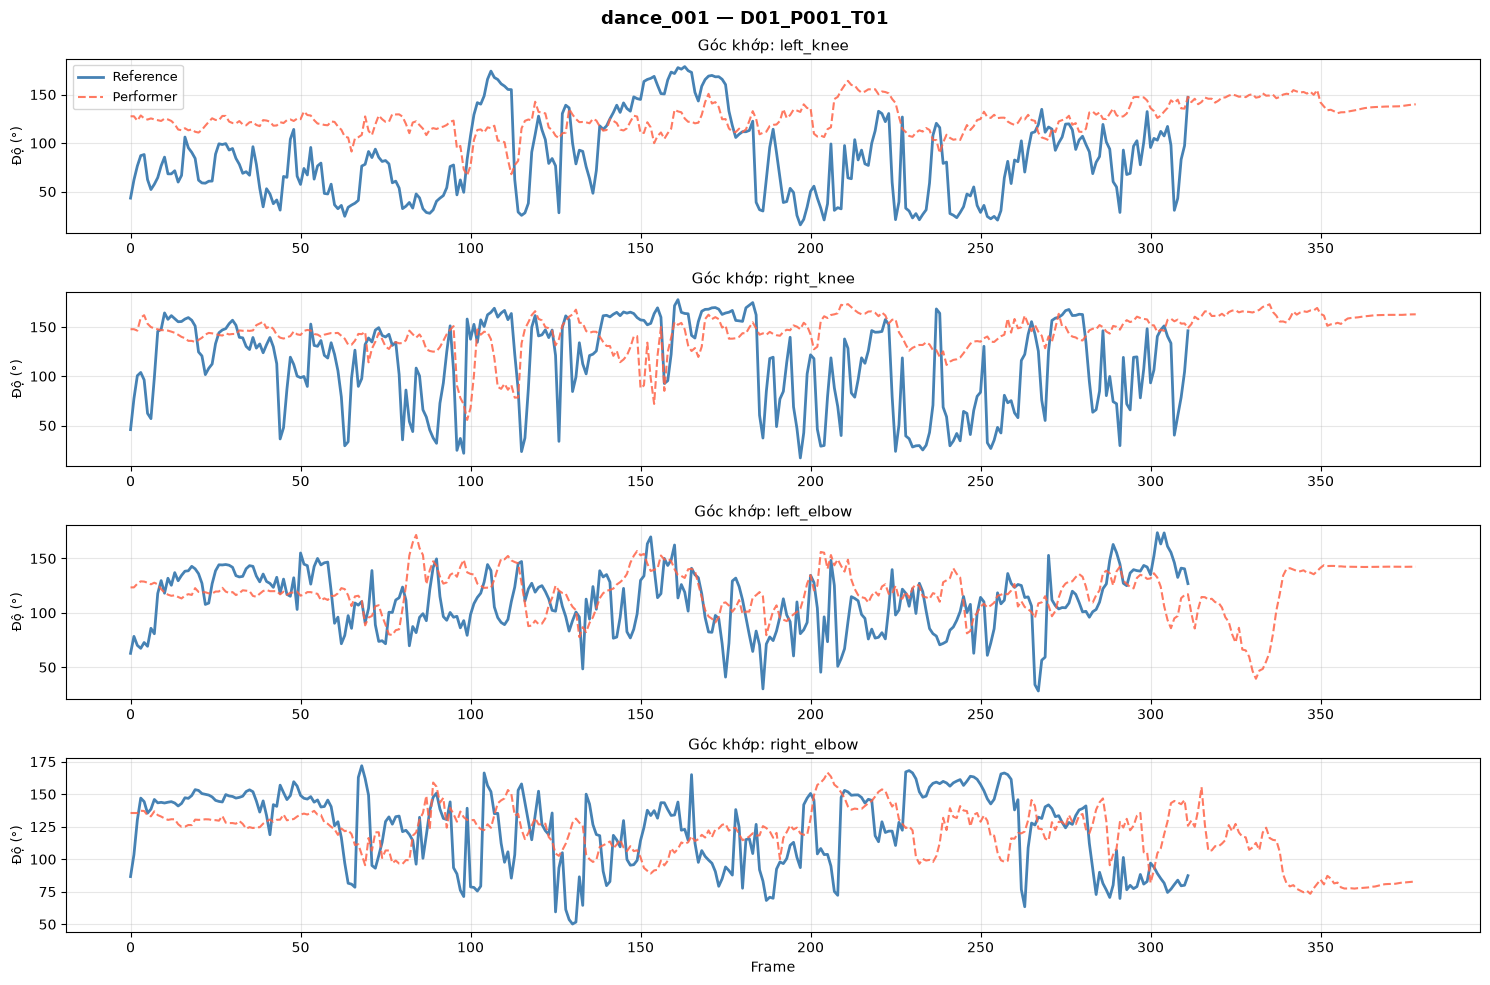

In [4]:
# ── Vẽ 4 góc đầu (gối + khuỷu tay) ────────────────────────────────────────
SHOW_IDX = [0, 1, 2, 3]   # left_knee, right_knee, left_elbow, right_elbow

fig, axes = plt.subplots(len(SHOW_IDX), 1, figsize=(15, 10), sharex=False)
for ax, idx in zip(axes, SHOW_IDX):
    ax.plot(ref_feat[:, idx],  label='Reference', lw=2,   color='steelblue')
    ax.plot(perf_feat[:, idx], label='Performer', lw=1.5, color='tomato', ls='--', alpha=0.85)
    ax.set_title(f'Góc khớp: {feature_names[idx]}', fontsize=11)
    ax.set_ylabel('Độ (°)', fontsize=9)
    ax.grid(True, alpha=0.3)
    if idx == SHOW_IDX[0]:
        ax.legend(fontsize=9)
axes[-1].set_xlabel('Frame')
plt.suptitle(f'{DANCE_ID} — {VIDEO_ID}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

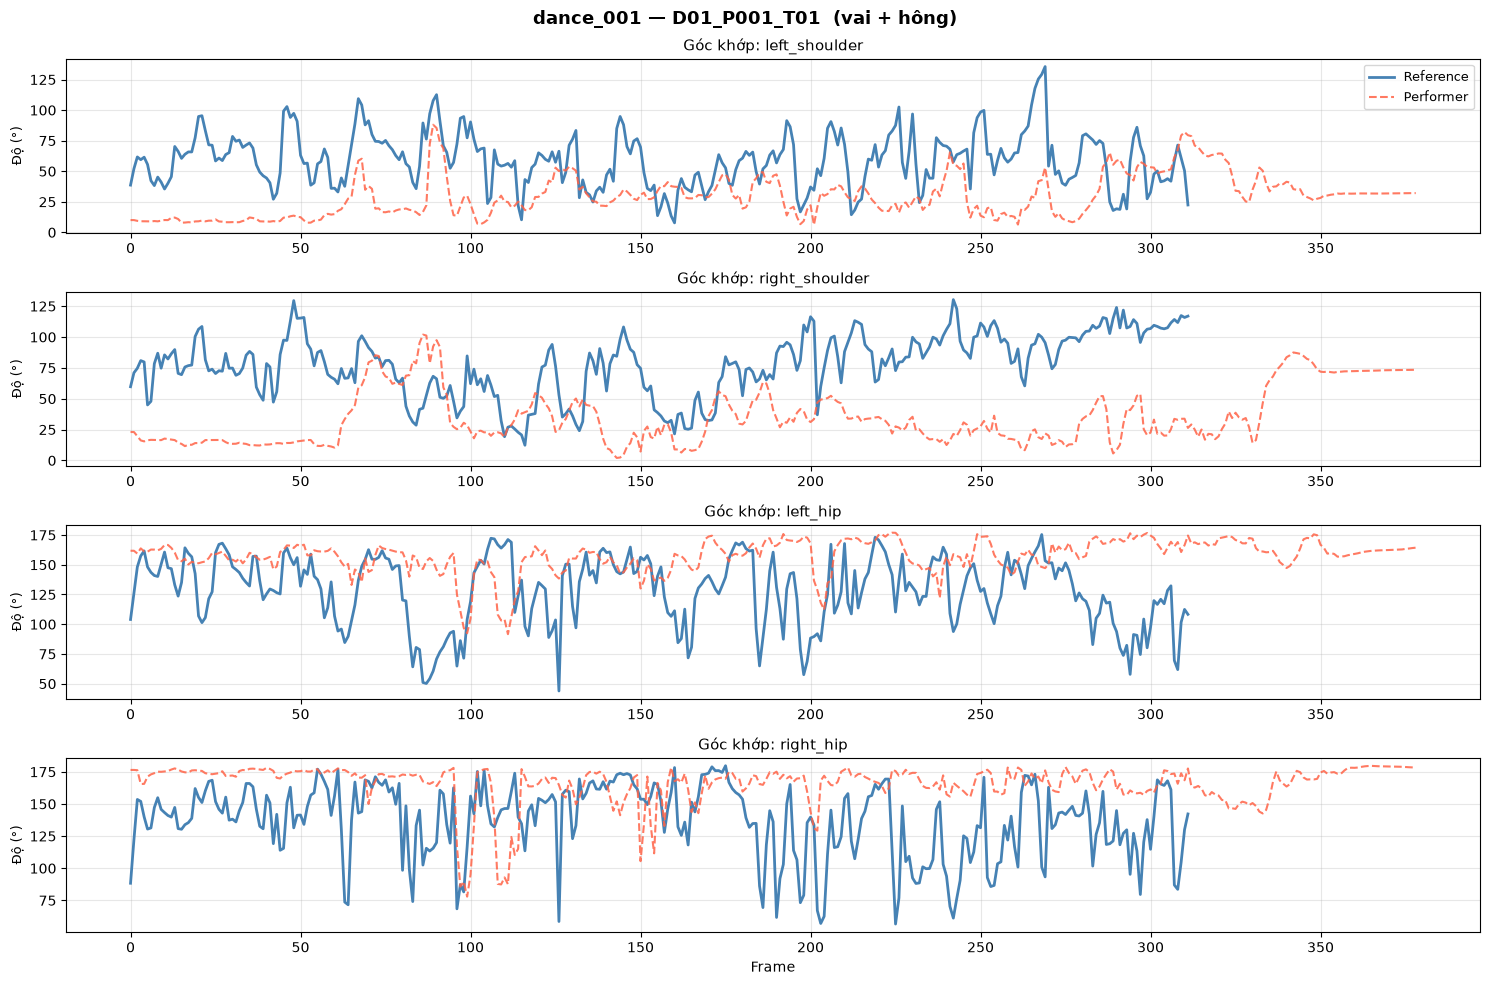

In [5]:
# ── Vẽ 4 góc còn lại (vai + hông) ─────────────────────────────────────────
SHOW_IDX2 = [4, 5, 6, 7]   # left_shoulder, right_shoulder, left_hip, right_hip

fig2, axes2 = plt.subplots(len(SHOW_IDX2), 1, figsize=(15, 10), sharex=False)
for ax, idx in zip(axes2, SHOW_IDX2):
    ax.plot(ref_feat[:, idx],  label='Reference', lw=2,   color='steelblue')
    ax.plot(perf_feat[:, idx], label='Performer', lw=1.5, color='tomato', ls='--', alpha=0.85)
    ax.set_title(f'Góc khớp: {feature_names[idx]}', fontsize=11)
    ax.set_ylabel('Độ (°)', fontsize=9)
    ax.grid(True, alpha=0.3)
    if idx == SHOW_IDX2[0]:
        ax.legend(fontsize=9)
axes2[-1].set_xlabel('Frame')
plt.suptitle(f'{DANCE_ID} — {VIDEO_ID}  (vai + hông)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 📝 Hướng dẫn quan sát
| Hiện tượng | Diễn giải |
|---|---|
| Đường performer (đỏ) lệch sang phải | **Lệch pha (timing)** — nhảy trễ hơn reference |
| Biên độ performer thấp hơn | **`low_amplitude`** — không đủ lực hoặc không kéo hết |
| Hình dạng đường performer khác hẳn | **`wrong_move`** — sai động tác/hướng |

Ở **Tuần 3**, hàm `dtw_align` (đã có trong `src/features/dtw.py`) sẽ co giãn trục thời gian để khớp 2 chuỗi. `dtw_distance_windowed` sẽ chỉ ra đoạn nào lệch nhiều nhất để Person 3 tập trung gán nhãn.